Device: cuda
GPU   : Tesla T4
train shape : (7500, 2)
test shape  : (2500, 2)
sample shape: (3, 2)


,image_path,label_name
0,data\food-101\images\data\food-101\images\hot_...,hot_and_sour_soup
1,data\food-101\images\data\food-101\images\hot_...,hot_and_sour_soup
2,data\food-101\images\data\food-101\images\hot_...,hot_and_sour_soup
3,data\food-101\images\data\food-101\images\hot_...,hot_and_sour_soup
4,data\food-101\images\data\food-101\images\hot_...,hot_and_sour_soup


,original_index,image_path
0,250,data\food-101\images\data\food-101\images\hot_...
1,251,data\food-101\images\data\food-101\images\hot_...
2,252,data\food-101\images\data\food-101\images\hot_...
3,253,data\food-101\images\data\food-101\images\hot_...
4,254,data\food-101\images\data\food-101\images\hot_...


classes: ['baby_back_ribs', 'beef_tartare', 'cheesecake', 'crab_cakes', 'dumplings', 'french_onion_soup', 'guacamole', 'hot_and_sour_soup', 'pork_chop', 'sushi']


label_name,baby_back_ribs,beef_tartare,cheesecake,crab_cakes,dumplings,french_onion_soup,guacamole,hot_and_sour_soup,pork_chop,sushi
fold,,,,,,,,,,
0,250,250,250,250,250,250,250,250,250,250
1,250,250,250,250,250,250,250,250,250,250
2,250,250,250,250,250,250,250,250,250,250


Using image root: /kaggle/input/datasets/kmader/food41/images
Missing train images: 0
Missing test images : 0


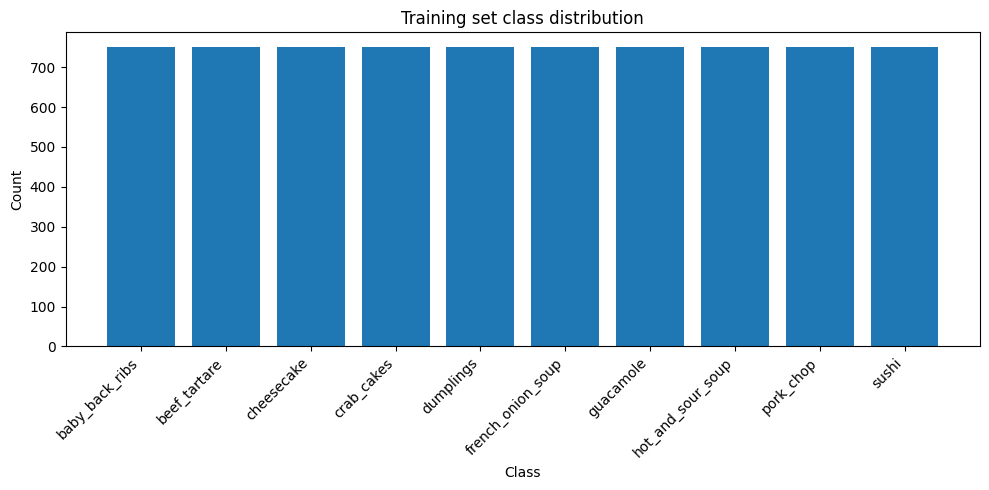

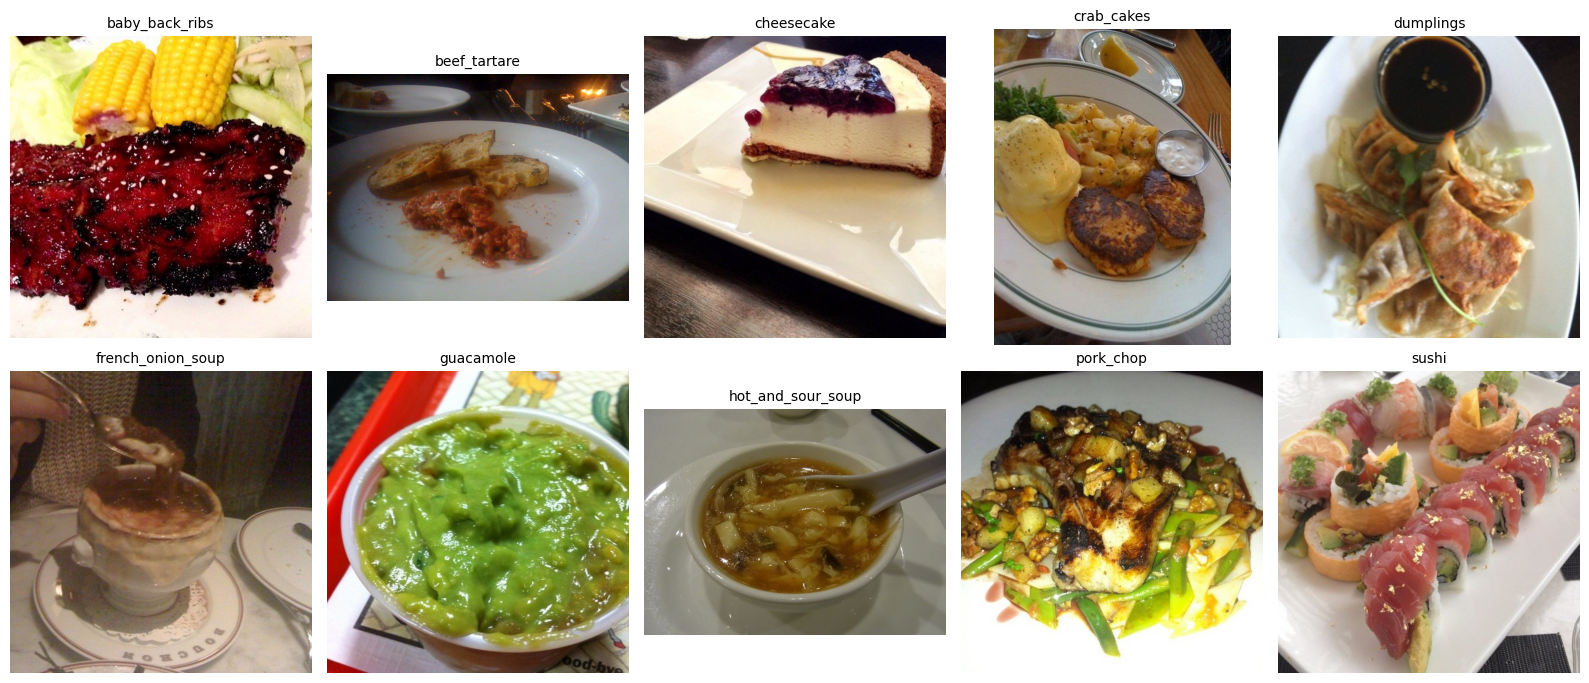

,count,mean,std,min,25%,50%,75%,max
width,500.0,494.44800,47.735360,287.000000,512.0,512.0,512.000000,512.000000
height,500.0,475.71400,65.273129,288.000000,493.0,512.0,512.000000,512.000000
aspect_ratio,500.0,1.06813,0.229779,0.560547,1.0,1.0,1.039013,1.777778


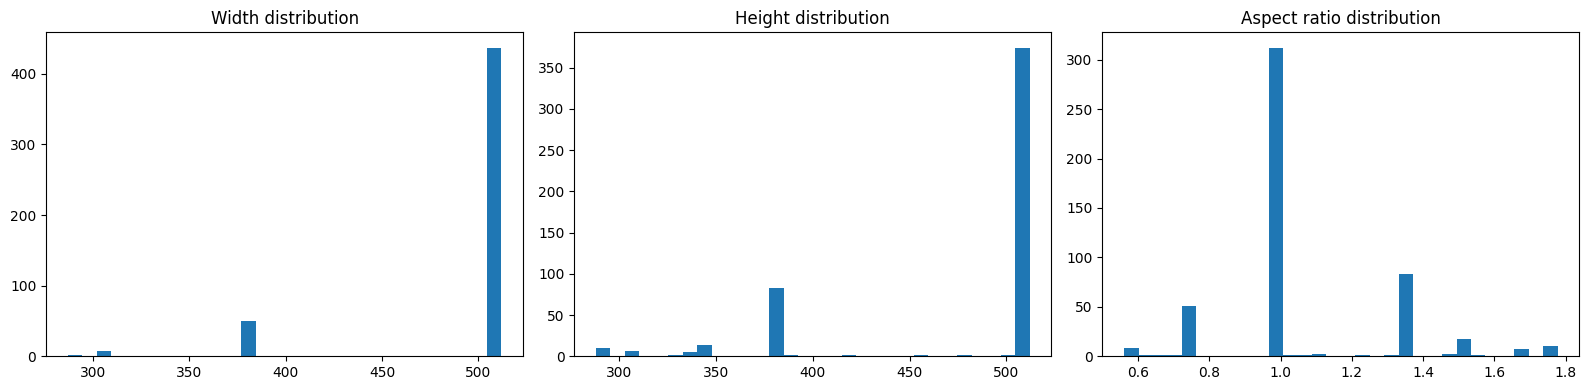

Artifacts saved to: /kaggle/working/task2_artifacts


In [1]:
#Setup, metadata, folds, clean artifacts


import os
import gc
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.model_selection import StratifiedKFold
from IPython.display import display

import torch

warnings.filterwarnings("ignore")


#Config
class CFG:
    seed = 42
    n_folds = 3
    size_stats_sample = 500
    work_dir = Path("/kaggle/working")
    artifact_dir = work_dir / "task2_artifacts"
    fig_dir = artifact_dir / "figures"
    meta_dir = artifact_dir / "metadata"

CFG.artifact_dir.mkdir(parents=True, exist_ok=True)
CFG.fig_dir.mkdir(parents=True, exist_ok=True)
CFG.meta_dir.mkdir(parents=True, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 70)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU   :", torch.cuda.get_device_name(0))
else:
    print("GPU   : not enabled")
print("=" * 70)

TRAIN_CSV_PATH = Path("/kaggle/input/competitions/pre-trained-models/train.csv.csv")
TEST_CSV_PATH = Path("/kaggle/input/competitions/pre-trained-models/test.csv")
SAMPLE_SUB_PATH = Path("/kaggle/input/competitions/pre-trained-models/sample_submission.csv")

train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print("train shape :", train_df.shape)
print("test shape  :", test_df.shape)
print("sample shape:", sample_sub.shape)

display(train_df.head())
display(test_df.head())

def normalize_food_path(path_str):
    s = str(path_str).replace("\\", "/").strip("/")
    parts = [p for p in s.split("/") if p]
    if len(parts) >= 2:
        return "/".join(parts[-2:])
    return s

train_df["rel_path"] = train_df["image_path"].apply(normalize_food_path)
test_df["rel_path"] = test_df["image_path"].apply(normalize_food_path)

class_names = sorted(train_df["label_name"].unique())
label2id = {name: idx for idx, name in enumerate(class_names)}
id2label = {idx: name for name, idx in label2id.items()}

train_df["label_id"] = train_df["label_name"].map(label2id)

with open(CFG.meta_dir / "label2id.json", "w") as f:
    json.dump(label2id, f, indent=2)

with open(CFG.meta_dir / "id2label.json", "w") as f:
    json.dump({str(k): v for k, v in id2label.items()}, f, indent=2)

print("classes:", class_names)

train_df["fold"] = -1
skf = StratifiedKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)

for fold, (_, val_idx) in enumerate(skf.split(train_df, train_df["label_id"])):
    train_df.loc[val_idx, "fold"] = fold

fold_table = pd.crosstab(train_df["fold"], train_df["label_name"])
display(fold_table)

train_df.to_csv(CFG.meta_dir / "train_folds_3fold.csv", index=False)

preferred_roots = [
    Path("/kaggle/input/datasets/kmader/food41/images"),
    Path("/kaggle/input/food-images-food-101/images"),
]

best_root = None
for p in preferred_roots:
    if p.exists():
        best_root = p
        break

if best_root is None:
    input_root = Path("/kaggle/input")
    candidates = []
    for p in input_root.rglob("*"):
        if p.is_dir() and p.name.lower() in {"images", "food-101", "food101"}:
            try:
                first_jpg = next(p.rglob("*.jpg"), None)
            except Exception:
                first_jpg = None
            if first_jpg is not None:
                candidates.append(p)

    if len(candidates) == 0:
        raise FileNotFoundError("Could not find a usable Food-101 image folder under /kaggle/input.")

    def score_root(root, rel_paths):
        return sum((root / rel).exists() for rel in rel_paths)

    probe = train_df["rel_path"].sample(min(200, len(train_df)), random_state=CFG.seed).tolist()
    scores = [(p, score_root(p, probe)) for p in candidates]
    scores = sorted(scores, key=lambda x: -x[1])
    best_root = scores[0][0]

print("Using image root:", best_root)

train_df["image_file"] = train_df["rel_path"].apply(lambda x: str(best_root / x))
test_df["image_file"] = test_df["rel_path"].apply(lambda x: str(best_root / x))

missing_train = (~train_df["image_file"].apply(lambda x: Path(x).exists())).sum()
missing_test = (~test_df["image_file"].apply(lambda x: Path(x).exists())).sum()

print("Missing train images:", missing_train)
print("Missing test images :", missing_test)

if missing_train != 0 or missing_test != 0:
    raise ValueError("Resolved image paths are incomplete. Stop and fix this before training.")


#Class distribution figure

class_counts = train_df["label_name"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(class_counts.index, class_counts.values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Training set class distribution")
plt.tight_layout()
plt.savefig(CFG.fig_dir / "class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

vis_df = (
    train_df.groupby("label_name", group_keys=False)
    .sample(n=1, random_state=CFG.seed)
    .reset_index(drop=True)
)

plt.figure(figsize=(16, 7))
for i, row in enumerate(vis_df.itertuples(index=False), 1):
    img = Image.open(row.image_file).convert("RGB")
    plt.subplot(2, 5, i)
    plt.imshow(img)
    plt.title(row.label_name, fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.savefig(CFG.fig_dir / "one_sample_per_class.png", dpi=200, bbox_inches="tight")
plt.show()

size_df = train_df.sample(min(CFG.size_stats_sample, len(train_df)), random_state=CFG.seed).copy()

widths, heights, ratios = [], [], []
for path in size_df["image_file"]:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
        ratios.append(w / h)

size_stats = pd.DataFrame({
    "width": widths,
    "height": heights,
    "aspect_ratio": ratios,
})

display(size_stats.describe().T)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(size_stats["width"], bins=30)
axes[0].set_title("Width distribution")

axes[1].hist(size_stats["height"], bins=30)
axes[1].set_title("Height distribution")

axes[2].hist(size_stats["aspect_ratio"], bins=30)
axes[2].set_title("Aspect ratio distribution")

plt.tight_layout()
plt.savefig(CFG.fig_dir / "image_size_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

size_stats.to_csv(CFG.meta_dir / "image_size_summary.csv", index=False)

train_df.to_csv(CFG.meta_dir / "train_metadata_clean.csv", index=False)
test_df.to_csv(CFG.meta_dir / "test_metadata_clean.csv", index=False)

run_summary = {
    "seed": CFG.seed,
    "n_folds": CFG.n_folds,
    "device": str(device),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "n_train": int(len(train_df)),
    "n_test": int(len(test_df)),
    "n_classes": int(len(class_names)),
    "class_names": class_names,
    "image_root": str(best_root),
}

with open(CFG.meta_dir / "run_summary.json", "w") as f:
    json.dump(run_summary, f, indent=2)

print("Artifacts saved to:", CFG.artifact_dir)
gc.collect()
torch.cuda.empty_cache()

In [2]:
#ConvNeXt Tiny - 3-fold production
import os
import gc
import time
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

import timm
from timm.data import resolve_data_config

warnings.filterwarnings("ignore")


class CFG:
    seed = 42

    model_tag = "convnext_tiny"
    model_name = "convnext_tiny.in12k_ft_in1k"
    image_size = 224

    n_folds = 3
    batch_size = 32
    num_workers = 2

    epochs = 4
    lr = 2e-3
    weight_decay = 1e-4
    max_grad_norm = 1.0
    label_smoothing = 0.0

    use_test_flip_tta = True

    base_dir = Path("/kaggle/working/task2_artifacts")
    meta_dir = base_dir / "metadata"
    model_dir = base_dir / "models"
    pred_dir = base_dir / "predictions"
    sub_dir = base_dir / "submissions"
    fig_dir = base_dir / "figures"


CFG.model_dir.mkdir(parents=True, exist_ok=True)
CFG.pred_dir.mkdir(parents=True, exist_ok=True)
CFG.sub_dir.mkdir(parents=True, exist_ok=True)
CFG.fig_dir.mkdir(parents=True, exist_ok=True)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)

torch.backends.cudnn.benchmark = True
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU   :", torch.cuda.get_device_name(0))


train_df = pd.read_csv(CFG.meta_dir / "train_metadata_clean.csv")
test_df = pd.read_csv(CFG.meta_dir / "test_metadata_clean.csv")

with open(CFG.meta_dir / "label2id.json", "r") as f:
    label2id = json.load(f)

id2label = {int(v): k for k, v in label2id.items()}
class_names = [id2label[i] for i in range(len(id2label))]
n_classes = len(class_names)

tmp_model = timm.create_model(CFG.model_name, pretrained=True, num_classes=n_classes)
data_cfg = resolve_data_config(tmp_model.pretrained_cfg, model=tmp_model)
mean = data_cfg["mean"]
std = data_cfg["std"]
crop_pct = data_cfg.get("crop_pct", 0.95)
del tmp_model
gc.collect()
torch.cuda.empty_cache()

print("Resolved data config:", data_cfg)


train_transform = T.Compose([
    T.RandomResizedCrop(CFG.image_size, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean, std),
])

val_transform = T.Compose([
    T.Resize(int(CFG.image_size / crop_pct)),
    T.CenterCrop(CFG.image_size),
    T.ToTensor(),
    T.Normalize(mean, std),
])

flip_tta_transform = T.Compose([
    T.Resize(int(CFG.image_size / crop_pct)),
    T.CenterCrop(CFG.image_size),
    T.RandomHorizontalFlip(p=1.0),
    T.ToTensor(),
    T.Normalize(mean, std),
])


class FoodDataset(Dataset):
    def __init__(self, df, transform=None, is_test=False):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_file"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        if self.is_test:
            return {
                "image": image,
                "original_index": int(row["original_index"]),
                "image_file": row["image_file"],
            }

        return {
            "image": image,
            "target": int(row["label_id"]),
            "image_file": row["image_file"],
        }


def make_loader(df, transform, is_test=False, shuffle=False, drop_last=False):
    ds = FoodDataset(df, transform=transform, is_test=is_test)
    return DataLoader(
        ds,
        batch_size=CFG.batch_size,
        shuffle=shuffle,
        num_workers=CFG.num_workers,
        pin_memory=True,
        drop_last=drop_last,
        persistent_workers=CFG.num_workers > 0,
    )


def freeze_backbone_only_train_head(model):
    for p in model.parameters():
        p.requires_grad = False
    classifier = model.get_classifier()
    for p in classifier.parameters():
        p.requires_grad = True


def build_model():
    model = timm.create_model(CFG.model_name, pretrained=True, num_classes=n_classes)
    freeze_backbone_only_train_head(model)
    return model.to(device)


def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


def run_train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["target"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.max_grad_norm)
        scaler.step(optimizer)
        scaler.update()

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, targets) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n


@torch.no_grad()
def run_eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    all_targets, all_preds, all_probs, all_paths = [], [], [], []

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["target"].to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, targets)

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_acc += (preds == targets).float().mean().item() * bs
        total_n += bs

        all_targets.extend(targets.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy())
        all_paths.extend(batch["image_file"])

    return (
        total_loss / total_n,
        total_acc / total_n,
        np.array(all_targets),
        np.array(all_preds),
        np.array(all_probs, dtype=np.float32),
        all_paths,
    )


@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    all_indices, all_probs = [], []

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
        all_indices.extend(batch["original_index"].cpu().numpy().tolist())
        all_probs.append(probs.cpu().numpy())

    return np.array(all_indices), np.concatenate(all_probs, axis=0).astype(np.float32)


criterion = nn.CrossEntropyLoss(label_smoothing=CFG.label_smoothing)

oof_probs = np.zeros((len(train_df), n_classes), dtype=np.float32)
oof_preds = np.zeros(len(train_df), dtype=np.int64)

test_probs_folds = []
fold_summaries = []
fold_histories = []

for fold in range(CFG.n_folds):
    print("\n" + "=" * 70)
    print(f"{CFG.model_tag} | fold {fold}")
    print("=" * 70)

    tr_df = train_df[train_df["fold"] != fold].copy().reset_index(drop=True)
    va_df = train_df[train_df["fold"] == fold].copy().reset_index(drop=True)

    train_loader = make_loader(tr_df, train_transform, is_test=False, shuffle=True)
    val_loader = make_loader(va_df, val_transform, is_test=False, shuffle=False)
    test_loader = make_loader(test_df, val_transform, is_test=True, shuffle=False)

    if CFG.use_test_flip_tta:
        test_loader_flip = make_loader(test_df, flip_tta_transform, is_test=True, shuffle=False)

    model = build_model()
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=CFG.lr, weight_decay=CFG.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.epochs)

    history = []
    best_val_acc = -1.0
    best_path = CFG.model_dir / f"{CFG.model_tag}_fold{fold}_headonly_best.pth"

    t0 = time.time()

    for epoch in range(1, CFG.epochs + 1):
        train_loss, train_acc = run_train_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_acc, val_targets, val_preds, val_probs, val_paths = run_eval_epoch(model, val_loader, criterion)
        scheduler.step()

        history.append({
            "fold": fold,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": optimizer.param_groups[0]["lr"],
        })

        print(
            f"epoch {epoch:02d}/{CFG.epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(
                {
                    "model_tag": CFG.model_tag,
                    "model_name": CFG.model_name,
                    "model_state_dict": model.state_dict(),
                    "val_acc": val_acc,
                    "epoch": epoch,
                    "fold": fold,
                    "image_size": CFG.image_size,
                    "class_names": class_names,
                },
                best_path
            )

    print(f"fold {fold} done in {(time.time() - t0)/60:.2f} min | best_val_acc={best_val_acc:.4f}")

    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])

    val_loss, val_acc, val_targets, val_preds, val_probs, val_paths = run_eval_epoch(model, val_loader, criterion)
    val_indices = train_df[train_df["fold"] == fold].index.to_numpy()

    oof_probs[val_indices] = val_probs
    oof_preds[val_indices] = val_preds

    fold_pred_df = pd.DataFrame({
        "image_file": val_paths,
        "target_id": val_targets,
        "pred_id": val_preds,
        "target_name": [id2label[int(x)] for x in val_targets],
        "pred_name": [id2label[int(x)] for x in val_preds],
        "max_prob": val_probs.max(axis=1),
        "correct": (val_targets == val_preds).astype(int),
        "fold": fold,
        "model_tag": CFG.model_tag,
    })
    fold_pred_df.to_csv(CFG.pred_dir / f"val_preds_{CFG.model_tag}_fold{fold}_headonly.csv", index=False)

    idx_test, probs_test = predict_probs(model, test_loader)

    if CFG.use_test_flip_tta:
        idx_test_flip, probs_test_flip = predict_probs(model, test_loader_flip)
        probs_test = 0.5 * probs_test + 0.5 * probs_test_flip

    order = np.argsort(idx_test)
    probs_test = probs_test[order]
    idx_test = idx_test[order]

    test_probs_folds.append(probs_test)

    cm = confusion_matrix(val_targets, val_preds, labels=list(range(n_classes)))
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    fold_summaries.append({
        "fold": fold,
        "best_val_acc": float(best_val_acc),
        "final_val_acc": float(val_acc),
        "worst_class": class_names[int(np.argmin(per_class_acc))],
        "worst_class_acc": float(per_class_acc.min()),
        "best_class": class_names[int(np.argmax(per_class_acc))],
        "best_class_acc": float(per_class_acc.max()),
    })
    fold_histories.append(pd.DataFrame(history))

    gc.collect()
    torch.cuda.empty_cache()


oof_target = train_df["label_id"].values
oof_acc = accuracy_score(oof_target, oof_preds)

print("\nOOF accuracy:", round(oof_acc, 6))

oof_df = train_df.copy()
for c in range(n_classes):
    oof_df[f"prob_{id2label[c]}"] = oof_probs[:, c]
oof_df["pred_id"] = oof_preds
oof_df["pred_name"] = [id2label[int(x)] for x in oof_preds]
oof_df["correct"] = (oof_target == oof_preds).astype(int)
oof_df.to_csv(CFG.pred_dir / f"oof_{CFG.model_tag}_headonly.csv", index=False)

fold_summary_df = pd.DataFrame(fold_summaries)
display(fold_summary_df)
fold_summary_df.to_csv(CFG.pred_dir / f"cv_summary_{CFG.model_tag}_headonly.csv", index=False)

weights = fold_summary_df["best_val_acc"].values.astype(np.float32)
weights = weights / weights.sum()

test_probs_mean = np.mean(test_probs_folds, axis=0).astype(np.float32)
test_probs_weighted = np.average(np.stack(test_probs_folds, axis=0), axis=0, weights=weights).astype(np.float32)

test_mean_df = test_df[["original_index", "image_file"]].copy()
test_weighted_df = test_df[["original_index", "image_file"]].copy()

for c in range(n_classes):
    cname = id2label[c]
    test_mean_df[f"prob_{cname}"] = test_probs_mean[:, c]
    test_weighted_df[f"prob_{cname}"] = test_probs_weighted[:, c]

test_mean_df["pred_id"] = test_probs_mean.argmax(axis=1)
test_mean_df["pred_name"] = [id2label[int(x)] for x in test_mean_df["pred_id"]]
test_weighted_df["pred_id"] = test_probs_weighted.argmax(axis=1)
test_weighted_df["pred_name"] = [id2label[int(x)] for x in test_weighted_df["pred_id"]]

test_mean_df = test_mean_df.sort_values("original_index").reset_index(drop=True)
test_weighted_df = test_weighted_df.sort_values("original_index").reset_index(drop=True)

test_mean_df.to_csv(CFG.pred_dir / f"test_probs_{CFG.model_tag}_headonly_mean.csv", index=False)
test_weighted_df.to_csv(CFG.pred_dir / f"test_probs_{CFG.model_tag}_headonly_weighted.csv", index=False)

sub_mean = test_df[["original_index"]].copy()
sub_mean["label_name"] = test_mean_df["pred_name"].values
sub_mean = sub_mean.sort_values("original_index").reset_index(drop=True)
sub_mean.to_csv(CFG.sub_dir / f"submission_{CFG.model_tag}_headonly_mean.csv", index=False)

sub_weighted = test_df[["original_index"]].copy()
sub_weighted["label_name"] = test_weighted_df["pred_name"].values
sub_weighted = sub_weighted.sort_values("original_index").reset_index(drop=True)
sub_weighted.to_csv(CFG.sub_dir / f"submission_{CFG.model_tag}_headonly_weighted.csv", index=False)

report_df = pd.DataFrame(
    classification_report(oof_target, oof_preds, target_names=class_names, digits=4, output_dict=True)
).T
report_df.to_csv(CFG.pred_dir / f"classification_report_oof_{CFG.model_tag}_headonly.csv")

cm = confusion_matrix(oof_target, oof_preds, labels=list(range(n_classes)))
per_class_acc = cm.diagonal() / cm.sum(axis=1)
per_class_df = pd.DataFrame({
    "class_name": class_names,
    "count": cm.sum(axis=1),
    "correct": cm.diagonal(),
    "per_class_acc": per_class_acc,
}).sort_values("per_class_acc", ascending=False)
per_class_df.to_csv(CFG.pred_dir / f"per_class_acc_oof_{CFG.model_tag}_headonly.csv", index=False)
display(per_class_df)

history_all_df = pd.concat(fold_histories, axis=0, ignore_index=True)
history_all_df.to_csv(CFG.pred_dir / f"history_allfolds_{CFG.model_tag}_headonly.csv", index=False)

summary = {
    "model_tag": CFG.model_tag,
    "model_name": CFG.model_name,
    "regime": "head_only",
    "n_folds": CFG.n_folds,
    "epochs": CFG.epochs,
    "batch_size": CFG.batch_size,
    "image_size": CFG.image_size,
    "oof_accuracy": float(oof_acc),
    "cv_mean_best_val_acc": float(fold_summary_df["best_val_acc"].mean()),
    "cv_std_best_val_acc": float(fold_summary_df["best_val_acc"].std()),
    "use_test_flip_tta": bool(CFG.use_test_flip_tta),
    "weighted_submission_path": str(CFG.sub_dir / f"submission_{CFG.model_tag}_headonly_weighted.csv"),
    "mean_submission_path": str(CFG.sub_dir / f"submission_{CFG.model_tag}_headonly_mean.csv"),
}

with open(CFG.pred_dir / f"summary_{CFG.model_tag}_headonly.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
gc.collect()
torch.cuda.empty_cache()

Device: cuda
GPU   : Tesla T4


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Resolved data config: {'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.95, 'crop_mode': 'center'}

convnext_tiny | fold 0
epoch 01/4 | train_loss=0.3120 train_acc=0.9024 | val_loss=0.2275 val_acc=0.9252
epoch 02/4 | train_loss=0.1485 train_acc=0.9518 | val_loss=0.2461 val_acc=0.9232
epoch 03/4 | train_loss=0.0970 train_acc=0.9658 | val_loss=0.2162 val_acc=0.9324
epoch 04/4 | train_loss=0.0619 train_acc=0.9810 | val_loss=0.2029 val_acc=0.9376
fold 0 done in 3.16 min | best_val_acc=0.9376

convnext_tiny | fold 1
epoch 01/4 | train_loss=0.3247 train_acc=0.8950 | val_loss=0.2437 val_acc=0.9188
epoch 02/4 | train_loss=0.1612 train_acc=0.9446 | val_loss=0.2093 val_acc=0.9280
epoch 03/4 | train_loss=0.0964 train_acc=0.9686 | val_loss=0.1885 val_acc=0.9388
epoch 04/4 | train_loss=0.0628 train_acc=0.9800 | val_loss=0.1892 val_acc=0.9436
fold 1 done in 2.58 min | best_val_acc=0.9436

convnext_tiny | fold 2
epoch 

,fold,best_val_acc,final_val_acc,worst_class,worst_class_acc,best_class,best_class_acc
0,0,0.9376,0.9376,pork_chop,0.876,hot_and_sour_soup,0.976
1,1,0.9436,0.9436,pork_chop,0.888,guacamole,0.988
2,2,0.9432,0.9432,pork_chop,0.828,guacamole,0.984


,class_name,count,correct,per_class_acc
6,guacamole,750,736,0.981333
7,hot_and_sour_soup,750,729,0.972000
2,cheesecake,750,726,0.968000
4,dumplings,750,721,0.961333
5,french_onion_soup,750,719,0.958667
0,baby_back_ribs,750,703,0.937333
9,sushi,750,695,0.926667
1,beef_tartare,750,692,0.922667
3,crab_cakes,750,692,0.922667
8,pork_chop,750,648,0.864000


{
  "model_tag": "convnext_tiny",
  "model_name": "convnext_tiny.in12k_ft_in1k",
  "regime": "head_only",
  "n_folds": 3,
  "epochs": 4,
  "batch_size": 32,
  "image_size": 224,
  "oof_accuracy": 0.9414666666666667,
  "cv_mean_best_val_acc": 0.9414666666666666,
  "cv_std_best_val_acc": 0.0033545988334424477,
  "use_test_flip_tta": true,
  "weighted_submission_path": "/kaggle/working/task2_artifacts/submissions/submission_convnext_tiny_headonly_weighted.csv",
  "mean_submission_path": "/kaggle/working/task2_artifacts/submissions/submission_convnext_tiny_headonly_mean.csv"
}


In [3]:
#ConvNeXt Small - 3-fold production
import os
import gc
import time
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

import timm
from timm.data import resolve_data_config

warnings.filterwarnings("ignore")


class CFG:
    seed = 42

    model_tag = "convnext_small"
    model_candidates = [
        "convnext_small.in12k_ft_in1k",
        "convnext_small.fb_in22k_ft_in1k",
        "convnext_small.fb_in1k",
    ]
    image_size = 224

    n_folds = 3
    batch_size = 16
    num_workers = 2

    epochs = 4
    lr = 2e-3
    weight_decay = 1e-4
    max_grad_norm = 1.0
    label_smoothing = 0.0

    use_test_flip_tta = True

    base_dir = Path("/kaggle/working/task2_artifacts")
    meta_dir = base_dir / "metadata"
    model_dir = base_dir / "models"
    pred_dir = base_dir / "predictions"
    sub_dir = base_dir / "submissions"


CFG.model_dir.mkdir(parents=True, exist_ok=True)
CFG.pred_dir.mkdir(parents=True, exist_ok=True)
CFG.sub_dir.mkdir(parents=True, exist_ok=True)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)

torch.backends.cudnn.benchmark = True
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU   :", torch.cuda.get_device_name(0))


def pick_model_name(candidates, n_classes):
    last_err = None
    for name in candidates:
        try:
            _ = timm.create_model(name, pretrained=True, num_classes=n_classes)
            return name
        except Exception as e:
            last_err = e
    raise RuntimeError(f"No usable ConvNeXt Small model found. Last error: {last_err}")


train_df = pd.read_csv(CFG.meta_dir / "train_metadata_clean.csv")
test_df = pd.read_csv(CFG.meta_dir / "test_metadata_clean.csv")

with open(CFG.meta_dir / "label2id.json", "r") as f:
    label2id = json.load(f)

id2label = {int(v): k for k, v in label2id.items()}
class_names = [id2label[i] for i in range(len(id2label))]
n_classes = len(class_names)

CFG.model_name = pick_model_name(CFG.model_candidates, n_classes)
print("Using model:", CFG.model_name)

tmp_model = timm.create_model(CFG.model_name, pretrained=True, num_classes=n_classes)
data_cfg = resolve_data_config(tmp_model.pretrained_cfg, model=tmp_model)
mean = data_cfg["mean"]
std = data_cfg["std"]
crop_pct = data_cfg.get("crop_pct", 0.95)
del tmp_model
gc.collect()
torch.cuda.empty_cache()

print("Resolved data config:", data_cfg)


train_transform = T.Compose([
    T.RandomResizedCrop(CFG.image_size, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean, std),
])

val_transform = T.Compose([
    T.Resize(int(CFG.image_size / crop_pct)),
    T.CenterCrop(CFG.image_size),
    T.ToTensor(),
    T.Normalize(mean, std),
])

flip_tta_transform = T.Compose([
    T.Resize(int(CFG.image_size / crop_pct)),
    T.CenterCrop(CFG.image_size),
    T.RandomHorizontalFlip(p=1.0),
    T.ToTensor(),
    T.Normalize(mean, std),
])


class FoodDataset(Dataset):
    def __init__(self, df, transform=None, is_test=False):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_file"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        if self.is_test:
            return {
                "image": image,
                "original_index": int(row["original_index"]),
                "image_file": row["image_file"],
            }

        return {
            "image": image,
            "target": int(row["label_id"]),
            "image_file": row["image_file"],
        }


def make_loader(df, transform, is_test=False, shuffle=False, drop_last=False):
    ds = FoodDataset(df, transform=transform, is_test=is_test)
    return DataLoader(
        ds,
        batch_size=CFG.batch_size,
        shuffle=shuffle,
        num_workers=CFG.num_workers,
        pin_memory=True,
        drop_last=drop_last,
        persistent_workers=CFG.num_workers > 0,
    )


def freeze_backbone_only_train_head(model):
    for p in model.parameters():
        p.requires_grad = False
    classifier = model.get_classifier()
    for p in classifier.parameters():
        p.requires_grad = True


def build_model():
    model = timm.create_model(CFG.model_name, pretrained=True, num_classes=n_classes)
    freeze_backbone_only_train_head(model)
    return model.to(device)


def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


def run_train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, total_acc, total_n = 0.0, 0.0, 0

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["target"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.max_grad_norm)
        scaler.step(optimizer)
        scaler.update()

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, targets) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n


@torch.no_grad()
def run_eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_acc, total_n = 0.0, 0.0, 0
    all_targets, all_preds, all_probs, all_paths = [], [], [], []

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["target"].to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, targets)

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_acc += (preds == targets).float().mean().item() * bs
        total_n += bs

        all_targets.extend(targets.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy())
        all_paths.extend(batch["image_file"])

    return (
        total_loss / total_n,
        total_acc / total_n,
        np.array(all_targets),
        np.array(all_preds),
        np.array(all_probs, dtype=np.float32),
        all_paths,
    )


@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    all_indices, all_probs = [], []

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
        all_indices.extend(batch["original_index"].cpu().numpy().tolist())
        all_probs.append(probs.cpu().numpy())

    return np.array(all_indices), np.concatenate(all_probs, axis=0).astype(np.float32)


criterion = nn.CrossEntropyLoss(label_smoothing=CFG.label_smoothing)

oof_probs = np.zeros((len(train_df), n_classes), dtype=np.float32)
oof_preds = np.zeros(len(train_df), dtype=np.int64)

test_probs_folds = []
fold_summaries = []
fold_histories = []

for fold in range(CFG.n_folds):
    print("\n" + "=" * 70)
    print(f"{CFG.model_tag} | fold {fold}")
    print("=" * 70)

    tr_df = train_df[train_df["fold"] != fold].copy().reset_index(drop=True)
    va_df = train_df[train_df["fold"] == fold].copy().reset_index(drop=True)

    train_loader = make_loader(tr_df, train_transform, is_test=False, shuffle=True)
    val_loader = make_loader(va_df, val_transform, is_test=False, shuffle=False)
    test_loader = make_loader(test_df, val_transform, is_test=True, shuffle=False)

    if CFG.use_test_flip_tta:
        test_loader_flip = make_loader(test_df, flip_tta_transform, is_test=True, shuffle=False)

    model = build_model()
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=CFG.lr, weight_decay=CFG.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.epochs)

    history = []
    best_val_acc = -1.0
    best_path = CFG.model_dir / f"{CFG.model_tag}_fold{fold}_headonly_best.pth"

    t0 = time.time()

    for epoch in range(1, CFG.epochs + 1):
        train_loss, train_acc = run_train_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_acc, val_targets, val_preds, val_probs, val_paths = run_eval_epoch(model, val_loader, criterion)
        scheduler.step()

        history.append({
            "fold": fold,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": optimizer.param_groups[0]["lr"],
        })

        print(
            f"epoch {epoch:02d}/{CFG.epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(
                {
                    "model_tag": CFG.model_tag,
                    "model_name": CFG.model_name,
                    "model_state_dict": model.state_dict(),
                    "val_acc": val_acc,
                    "epoch": epoch,
                    "fold": fold,
                    "image_size": CFG.image_size,
                    "class_names": class_names,
                },
                best_path
            )

    print(f"fold {fold} done in {(time.time() - t0)/60:.2f} min | best_val_acc={best_val_acc:.4f}")

    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])

    val_loss, val_acc, val_targets, val_preds, val_probs, val_paths = run_eval_epoch(model, val_loader, criterion)
    val_indices = train_df[train_df["fold"] == fold].index.to_numpy()

    oof_probs[val_indices] = val_probs
    oof_preds[val_indices] = val_preds

    fold_pred_df = pd.DataFrame({
        "image_file": val_paths,
        "target_id": val_targets,
        "pred_id": val_preds,
        "target_name": [id2label[int(x)] for x in val_targets],
        "pred_name": [id2label[int(x)] for x in val_preds],
        "max_prob": val_probs.max(axis=1),
        "correct": (val_targets == val_preds).astype(int),
        "fold": fold,
        "model_tag": CFG.model_tag,
    })
    fold_pred_df.to_csv(CFG.pred_dir / f"val_preds_{CFG.model_tag}_fold{fold}_headonly.csv", index=False)

    idx_test, probs_test = predict_probs(model, test_loader)

    if CFG.use_test_flip_tta:
        idx_test_flip, probs_test_flip = predict_probs(model, test_loader_flip)
        probs_test = 0.5 * probs_test + 0.5 * probs_test_flip

    order = np.argsort(idx_test)
    probs_test = probs_test[order]
    idx_test = idx_test[order]

    test_probs_folds.append(probs_test)

    cm = confusion_matrix(val_targets, val_preds, labels=list(range(n_classes)))
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    fold_summaries.append({
        "fold": fold,
        "best_val_acc": float(best_val_acc),
        "final_val_acc": float(val_acc),
        "worst_class": class_names[int(np.argmin(per_class_acc))],
        "worst_class_acc": float(per_class_acc.min()),
        "best_class": class_names[int(np.argmax(per_class_acc))],
        "best_class_acc": float(per_class_acc.max()),
    })
    fold_histories.append(pd.DataFrame(history))

    gc.collect()
    torch.cuda.empty_cache()


oof_target = train_df["label_id"].values
oof_acc = accuracy_score(oof_target, oof_preds)

print("\nOOF accuracy:", round(oof_acc, 6))

oof_df = train_df.copy()
for c in range(n_classes):
    oof_df[f"prob_{id2label[c]}"] = oof_probs[:, c]
oof_df["pred_id"] = oof_preds
oof_df["pred_name"] = [id2label[int(x)] for x in oof_preds]
oof_df["correct"] = (oof_target == oof_preds).astype(int)
oof_df.to_csv(CFG.pred_dir / f"oof_{CFG.model_tag}_headonly.csv", index=False)

fold_summary_df = pd.DataFrame(fold_summaries)
display(fold_summary_df)
fold_summary_df.to_csv(CFG.pred_dir / f"cv_summary_{CFG.model_tag}_headonly.csv", index=False)

weights = fold_summary_df["best_val_acc"].values.astype(np.float32)
weights = weights / weights.sum()

test_probs_mean = np.mean(test_probs_folds, axis=0).astype(np.float32)
test_probs_weighted = np.average(np.stack(test_probs_folds, axis=0), axis=0, weights=weights).astype(np.float32)

test_mean_df = test_df[["original_index", "image_file"]].copy()
test_weighted_df = test_df[["original_index", "image_file"]].copy()

for c in range(n_classes):
    cname = id2label[c]
    test_mean_df[f"prob_{cname}"] = test_probs_mean[:, c]
    test_weighted_df[f"prob_{cname}"] = test_probs_weighted[:, c]

test_mean_df["pred_id"] = test_probs_mean.argmax(axis=1)
test_mean_df["pred_name"] = [id2label[int(x)] for x in test_mean_df["pred_id"]]
test_weighted_df["pred_id"] = test_probs_weighted.argmax(axis=1)
test_weighted_df["pred_name"] = [id2label[int(x)] for x in test_weighted_df["pred_id"]]

test_mean_df = test_mean_df.sort_values("original_index").reset_index(drop=True)
test_weighted_df = test_weighted_df.sort_values("original_index").reset_index(drop=True)

test_mean_df.to_csv(CFG.pred_dir / f"test_probs_{CFG.model_tag}_headonly_mean.csv", index=False)
test_weighted_df.to_csv(CFG.pred_dir / f"test_probs_{CFG.model_tag}_headonly_weighted.csv", index=False)

sub_mean = test_df[["original_index"]].copy()
sub_mean["label_name"] = test_mean_df["pred_name"].values
sub_mean = sub_mean.sort_values("original_index").reset_index(drop=True)
sub_mean.to_csv(CFG.sub_dir / f"submission_{CFG.model_tag}_headonly_mean.csv", index=False)

sub_weighted = test_df[["original_index"]].copy()
sub_weighted["label_name"] = test_weighted_df["pred_name"].values
sub_weighted = sub_weighted.sort_values("original_index").reset_index(drop=True)
sub_weighted.to_csv(CFG.sub_dir / f"submission_{CFG.model_tag}_headonly_weighted.csv", index=False)

report_df = pd.DataFrame(
    classification_report(oof_target, oof_preds, target_names=class_names, digits=4, output_dict=True)
).T
report_df.to_csv(CFG.pred_dir / f"classification_report_oof_{CFG.model_tag}_headonly.csv")

cm = confusion_matrix(oof_target, oof_preds, labels=list(range(n_classes)))
per_class_acc = cm.diagonal() / cm.sum(axis=1)
per_class_df = pd.DataFrame({
    "class_name": class_names,
    "count": cm.sum(axis=1),
    "correct": cm.diagonal(),
    "per_class_acc": per_class_acc,
}).sort_values("per_class_acc", ascending=False)
per_class_df.to_csv(CFG.pred_dir / f"per_class_acc_oof_{CFG.model_tag}_headonly.csv", index=False)
display(per_class_df)

history_all_df = pd.concat(fold_histories, axis=0, ignore_index=True)
history_all_df.to_csv(CFG.pred_dir / f"history_allfolds_{CFG.model_tag}_headonly.csv", index=False)

summary = {
    "model_tag": CFG.model_tag,
    "model_name": CFG.model_name,
    "regime": "head_only",
    "n_folds": CFG.n_folds,
    "epochs": CFG.epochs,
    "batch_size": CFG.batch_size,
    "image_size": CFG.image_size,
    "oof_accuracy": float(oof_acc),
    "cv_mean_best_val_acc": float(fold_summary_df["best_val_acc"].mean()),
    "cv_std_best_val_acc": float(fold_summary_df["best_val_acc"].std()),
    "use_test_flip_tta": bool(CFG.use_test_flip_tta),
    "weighted_submission_path": str(CFG.sub_dir / f"submission_{CFG.model_tag}_headonly_weighted.csv"),
    "mean_submission_path": str(CFG.sub_dir / f"submission_{CFG.model_tag}_headonly_mean.csv"),
}

with open(CFG.pred_dir / f"summary_{CFG.model_tag}_headonly.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
gc.collect()
torch.cuda.empty_cache()

Device: cuda
GPU   : Tesla T4


model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

Using model: convnext_small.in12k_ft_in1k
Resolved data config: {'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.95, 'crop_mode': 'center'}

convnext_small | fold 0


epoch 01/4 | train_loss=0.2974 train_acc=0.9100 | val_loss=0.3777 val_acc=0.9088
epoch 02/4 | train_loss=0.1463 train_acc=0.9550 | val_loss=0.2714 val_acc=0.9244
epoch 03/4 | train_loss=0.0761 train_acc=0.9746 | val_loss=0.2664 val_acc=0.9352
epoch 04/4 | train_loss=0.0428 train_acc=0.9852 | val_loss=0.2507 val_acc=0.9376
fold 0 done in 2.83 min | best_val_acc=0.9376

convnext_small | fold 1
epoch 01/4 | train_loss=0.3264 train_acc=0.9004 | val_loss=0.2114 val_acc=0.9420
epoch 02/4 | train_loss=0.1535 train_acc=0.9510 | val_loss=0.2082 val_acc=0.9420
epoch 03/4 | train_loss=0.0902 train_acc=0.9712 | val_loss=0.1909 val_acc=0.9472
epoch 04/4 | train_loss=0.0515 train_acc=0.9830 | val_loss=0.1871 val_acc=0.9464
fold 1 done in 2.68 min | best_val_acc=0.9472

convnext_small | fold 2
epoch 01/4 | train_loss=0.3059 train_acc=0.9050 | val_loss=0.2341 val_acc=0.9336
epoch 02/4 | train_loss=0.1549 train_acc=0.9520 | val_loss=0.2566 val_acc=0.9356
epoch 03/4 | train_loss=0.0849 train_acc=0.9716 

,fold,best_val_acc,final_val_acc,worst_class,worst_class_acc,best_class,best_class_acc
0,0,0.9376,0.9376,baby_back_ribs,0.88,hot_and_sour_soup,0.984
1,1,0.9472,0.9472,crab_cakes,0.90,hot_and_sour_soup,0.988
2,2,0.9440,0.9440,pork_chop,0.88,hot_and_sour_soup,0.980


,class_name,count,correct,per_class_acc
7,hot_and_sour_soup,750,738,0.984000
2,cheesecake,750,732,0.976000
6,guacamole,750,726,0.968000
4,dumplings,750,718,0.957333
5,french_onion_soup,750,711,0.948000
1,beef_tartare,750,705,0.940000
9,sushi,750,701,0.934667
0,baby_back_ribs,750,686,0.914667
3,crab_cakes,750,686,0.914667
8,pork_chop,750,669,0.892000


{
  "model_tag": "convnext_small",
  "model_name": "convnext_small.in12k_ft_in1k",
  "regime": "head_only",
  "n_folds": 3,
  "epochs": 4,
  "batch_size": 16,
  "image_size": 224,
  "oof_accuracy": 0.9429333333333333,
  "cv_mean_best_val_acc": 0.9429333333333334,
  "cv_std_best_val_acc": 0.004888080741286248,
  "use_test_flip_tta": true,
  "weighted_submission_path": "/kaggle/working/task2_artifacts/submissions/submission_convnext_small_headonly_weighted.csv",
  "mean_submission_path": "/kaggle/working/task2_artifacts/submissions/submission_convnext_small_headonly_mean.csv"
}


In [4]:
#ConvNeXt Tiny + ConvNeXt Small + strong TTA + OOF-safe stacking + balanced submissions


import os
import gc
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.transforms import InterpolationMode

import timm
from timm.data import resolve_data_config

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from scipy.optimize import linear_sum_assignment

warnings.filterwarnings("ignore")


class CFG:
    seed = 42

    base_dir = Path("/kaggle/working/task2_artifacts")
    meta_dir = base_dir / "metadata"
    model_dir = base_dir / "models"
    pred_dir = base_dir / "predictions"
    sub_dir = base_dir / "submissions"
    final_dir = base_dir / "final_supermax_v2"

    n_folds = 3
    num_workers = 2
    batch_size_infer = 64

    tiny_tag = "convnext_tiny"
    small_tag = "convnext_small"

    tiny_tta_specs = [
        {"name": "cp100", "crop_pct": 1.00, "hflip": False},
        {"name": "cp100_flip", "crop_pct": 1.00, "hflip": True},
        {"name": "cp095", "crop_pct": 0.95, "hflip": False},
        {"name": "cp095_flip", "crop_pct": 0.95, "hflip": True},
        {"name": "cp090", "crop_pct": 0.90, "hflip": False},
        {"name": "cp090_flip", "crop_pct": 0.90, "hflip": True},
        {"name": "cp085", "crop_pct": 0.85, "hflip": False},
        {"name": "cp085_flip", "crop_pct": 0.85, "hflip": True},
    ]

    small_tta_specs = [
        {"name": "cp100", "crop_pct": 1.00, "hflip": False},
        {"name": "cp100_flip", "crop_pct": 1.00, "hflip": True},
        {"name": "cp095", "crop_pct": 0.95, "hflip": False},
        {"name": "cp095_flip", "crop_pct": 0.95, "hflip": True},
        {"name": "cp090", "crop_pct": 0.90, "hflip": False},
        {"name": "cp090_flip", "crop_pct": 0.90, "hflip": True},
        {"name": "cp085", "crop_pct": 0.85, "hflip": False},
        {"name": "cp085_flip", "crop_pct": 0.85, "hflip": True},
    ]

    family_alpha_grid = np.linspace(0.0, 1.0, 41)
    model_gamma_grid = np.linspace(0.0, 1.0, 41)
    stack_c_grid = [0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]

    quota_per_class_oof_fold = 250
    quota_per_class_test = 250
    sharpen_grid = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20, 1.30, 1.40]


CFG.final_dir.mkdir(parents=True, exist_ok=True)
CFG.sub_dir.mkdir(parents=True, exist_ok=True)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)

torch.backends.cudnn.benchmark = True
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU   :", torch.cuda.get_device_name(0))


train_df = pd.read_csv(CFG.meta_dir / "train_metadata_clean.csv")
test_df = pd.read_csv(CFG.meta_dir / "test_metadata_clean.csv")

with open(CFG.meta_dir / "label2id.json", "r") as f:
    label2id = json.load(f)

id2label = {int(v): k for k, v in label2id.items()}
class_names = [id2label[i] for i in range(len(id2label))]
n_classes = len(class_names)

y_true = train_df["label_id"].values
fold_ids = train_df["fold"].values


EPS = 1e-9

def get_prob_columns(df):
    return [c for c in df.columns if c.startswith("prob_")]

def align_oof_probs(path, train_ref):
    df = pd.read_csv(path)
    prob_cols = get_prob_columns(df)
    merged = train_ref[["image_file"]].merge(df[["image_file"] + prob_cols], on="image_file", how="left")
    probs = merged[prob_cols].values.astype(np.float32)
    if np.isnan(probs).any():
        raise ValueError(f"NaNs while loading {path}")
    return probs

def align_test_probs(path, test_ref):
    df = pd.read_csv(path)
    prob_cols = get_prob_columns(df)
    merged = test_ref[["original_index"]].merge(df[["original_index"] + prob_cols], on="original_index", how="left")
    probs = merged[prob_cols].values.astype(np.float32)
    if np.isnan(probs).any():
        raise ValueError(f"NaNs while loading {path}")
    return probs

def argmax_acc(probs, y):
    return float((probs.argmax(axis=1) == y).mean())

def linear_blend(p1, p2, w1):
    return (w1 * p1 + (1.0 - w1) * p2).astype(np.float32)

def geom_blend(p1, p2, w1):
    logp = w1 * np.log(np.clip(p1, EPS, 1.0)) + (1.0 - w1) * np.log(np.clip(p2, EPS, 1.0))
    out = np.exp(logp)
    out /= out.sum(axis=1, keepdims=True)
    return out.astype(np.float32)

def blend_three(p1, p2, w1, mode="linear"):
    if mode == "linear":
        return linear_blend(p1, p2, w1)
    return geom_blend(p1, p2, w1)

def sharpen_probs(probs, power):
    p = np.clip(probs, EPS, 1.0) ** power
    p /= p.sum(axis=1, keepdims=True)
    return p.astype(np.float32)

def save_submission(pred_ids, path):
    sub = test_df[["original_index"]].copy()
    sub["label_name"] = [id2label[int(x)] for x in pred_ids]
    sub = sub.sort_values("original_index").reset_index(drop=True)
    sub.to_csv(path, index=False)
    return sub

def quota_assign(probs, quota_per_class):
    n_samples, n_cls = probs.shape
    assert n_samples == quota_per_class * n_cls
    slots = np.repeat(np.arange(n_cls), quota_per_class)
    cost = -np.log(np.clip(probs[:, slots], EPS, 1.0)).astype(np.float32)
    row_ind, col_ind = linear_sum_assignment(cost)
    pred = np.empty(n_samples, dtype=np.int64)
    pred[row_ind] = slots[col_ind]
    return pred

def balanced_oof_accuracy(probs, y, fold_ids, quota_per_class):
    preds = np.empty(len(y), dtype=np.int64)
    for fold in sorted(np.unique(fold_ids)):
        idx = np.where(fold_ids == fold)[0]
        preds[idx] = quota_assign(probs[idx], quota_per_class)
    return float((preds == y).mean()), preds

def make_resize_size(image_size, crop_pct):
    return int(math.ceil(image_size / crop_pct))

def build_transform(image_size, mean, std, crop_pct, hflip):
    resize_size = make_resize_size(image_size, crop_pct)
    ops = [
        T.Resize(resize_size, interpolation=InterpolationMode.BICUBIC),
        T.CenterCrop(image_size),
    ]
    if hflip:
        ops.append(T.RandomHorizontalFlip(p=1.0))
    ops.extend([
        T.ToTensor(),
        T.Normalize(mean, std),
    ])
    return T.Compose(ops)

def entropy_features(p):
    ent = -(p * np.log(np.clip(p, EPS, 1.0))).sum(axis=1, keepdims=True)
    s = np.sort(p, axis=1)
    top1 = s[:, -1:]
    top2 = s[:, -2:-1]
    margin = top1 - top2
    return np.hstack([top1, top2, margin, ent]).astype(np.float32)

def make_features(prob_list, mode):
    if mode == "raw":
        return np.hstack(prob_list).astype(np.float32)
    if mode == "log":
        return np.hstack([np.log(np.clip(p, EPS, 1.0)) for p in prob_list]).astype(np.float32)
    if mode == "hybrid":
        feats = []
        for p in prob_list:
            feats.append(p.astype(np.float32))
            feats.append(np.log(np.clip(p, EPS, 1.0)).astype(np.float32))
            feats.append(entropy_features(p))
        return np.hstack(feats).astype(np.float32)
    raise ValueError("Unknown feature mode")

tiny_summary = json.load(open(CFG.pred_dir / "summary_convnext_tiny_headonly.json"))
small_summary = json.load(open(CFG.pred_dir / "summary_convnext_small_headonly.json"))

tiny_name = tiny_summary["model_name"]
small_name = small_summary["model_name"]

tiny_base_oof = align_oof_probs(CFG.pred_dir / "oof_convnext_tiny_headonly.csv", train_df)
small_base_oof = align_oof_probs(CFG.pred_dir / "oof_convnext_small_headonly.csv", train_df)

tiny_base_test_weighted = align_test_probs(CFG.pred_dir / "test_probs_convnext_tiny_headonly_weighted.csv", test_df)
tiny_base_test_mean = align_test_probs(CFG.pred_dir / "test_probs_convnext_tiny_headonly_mean.csv", test_df)

small_base_test_weighted = align_test_probs(CFG.pred_dir / "test_probs_convnext_small_headonly_weighted.csv", test_df)
small_base_test_mean = align_test_probs(CFG.pred_dir / "test_probs_convnext_small_headonly_mean.csv", test_df)

print("tiny base OOF :", round(argmax_acc(tiny_base_oof, y_true), 6))
print("small base OOF:", round(argmax_acc(small_base_oof, y_true), 6))


# -------------------------
# Strong TTA inference from checkpoints
# -------------------------
class InferDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform, id_col):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.id_col = id_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_file"]).convert("RGB")
        image = self.transform(image)
        return {
            "image": image,
            "row_id": int(row[self.id_col]),
        }


@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    all_ids, all_probs = [], []

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
        all_ids.extend(batch["row_id"].cpu().numpy().tolist())
        all_probs.append(probs.cpu().numpy())

    return np.array(all_ids), np.concatenate(all_probs, axis=0).astype(np.float32)


def get_model_norm(model_name):
    tmp = timm.create_model(model_name, pretrained=True, num_classes=n_classes)
    data_cfg = resolve_data_config(tmp.pretrained_cfg, model=tmp)
    mean = data_cfg["mean"]
    std = data_cfg["std"]
    del tmp
    gc.collect()
    torch.cuda.empty_cache()
    return mean, std

def build_model_from_ckpt(model_name, ckpt_path):
    model = timm.create_model(model_name, pretrained=False, num_classes=n_classes).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    return model

def strong_tta_from_checkpoints(model_tag, model_name, image_size, tta_specs):
    mean, std = get_model_norm(model_name)

    cv_summary = pd.read_csv(CFG.pred_dir / f"cv_summary_{model_tag}_headonly.csv").sort_values("fold").reset_index(drop=True)
    weights = cv_summary["best_val_acc"].values.astype(np.float32)
    weights = weights / weights.sum()

    oof_probs = np.zeros((len(train_df), n_classes), dtype=np.float32)
    test_fold_probs = []

    for fold in range(CFG.n_folds):
        print(f"{model_tag} strong TTA | fold {fold}")

        ckpt_path = CFG.model_dir / f"{model_tag}_fold{fold}_headonly_best.pth"
        model = build_model_from_ckpt(model_name, ckpt_path)

        va_df = train_df[train_df["fold"] == fold].copy()
        va_df["row_idx"] = va_df.index

        te_df = test_df.copy()

        val_views = []
        test_views = []

        for spec in tta_specs:
            transform = build_transform(
                image_size=image_size,
                mean=mean,
                std=std,
                crop_pct=spec["crop_pct"],
                hflip=spec["hflip"],
            )

            val_ds = InferDataset(va_df, transform=transform, id_col="row_idx")
            test_ds = InferDataset(te_df, transform=transform, id_col="original_index")

            val_loader = DataLoader(
                val_ds,
                batch_size=CFG.batch_size_infer,
                shuffle=False,
                num_workers=CFG.num_workers,
                pin_memory=True,
                drop_last=False,
                persistent_workers=CFG.num_workers > 0,
            )
            test_loader = DataLoader(
                test_ds,
                batch_size=CFG.batch_size_infer,
                shuffle=False,
                num_workers=CFG.num_workers,
                pin_memory=True,
                drop_last=False,
                persistent_workers=CFG.num_workers > 0,
            )

            val_ids, val_probs = predict_probs(model, val_loader)
            test_ids, test_probs = predict_probs(model, test_loader)

            val_probs = val_probs[np.argsort(val_ids)]
            test_probs = test_probs[np.argsort(test_ids)]

            val_views.append(val_probs)
            test_views.append(test_probs)

        fold_val_probs = np.mean(val_views, axis=0).astype(np.float32)
        fold_test_probs = np.mean(test_views, axis=0).astype(np.float32)

        oof_probs[va_df.index.values] = fold_val_probs
        test_fold_probs.append(fold_test_probs)

        del model
        gc.collect()
        torch.cuda.empty_cache()

    test_mean = np.mean(test_fold_probs, axis=0).astype(np.float32)
    test_weighted = np.average(np.stack(test_fold_probs, axis=0), axis=0, weights=weights).astype(np.float32)

    return oof_probs, test_mean, test_weighted


tiny_tta_oof, tiny_tta_test_mean, tiny_tta_test_weighted = strong_tta_from_checkpoints(
    model_tag=CFG.tiny_tag,
    model_name=tiny_name,
    image_size=tiny_summary["image_size"],
    tta_specs=CFG.tiny_tta_specs,
)

small_tta_oof, small_tta_test_mean, small_tta_test_weighted = strong_tta_from_checkpoints(
    model_tag=CFG.small_tag,
    model_name=small_name,
    image_size=small_summary["image_size"],
    tta_specs=CFG.small_tta_specs,
)

print("tiny strong TTA OOF :", round(argmax_acc(tiny_tta_oof, y_true), 6))
print("small strong TTA OOF:", round(argmax_acc(small_tta_oof, y_true), 6))

family_rows = []

best_tiny = {"mode": None, "alpha": None, "oof_acc": -1.0, "oof_probs": None}
for mode in ["linear", "geom"]:
    for alpha in CFG.family_alpha_grid:
        probs = blend_three(tiny_base_oof, tiny_tta_oof, alpha, mode=mode)
        acc = argmax_acc(probs, y_true)
        family_rows.append({"family": "tiny", "mode": mode, "alpha": alpha, "oof_acc": acc})
        if acc > best_tiny["oof_acc"]:
            best_tiny = {"mode": mode, "alpha": alpha, "oof_acc": acc, "oof_probs": probs.copy()}

best_small = {"mode": None, "alpha": None, "oof_acc": -1.0, "oof_probs": None}
for mode in ["linear", "geom"]:
    for alpha in CFG.family_alpha_grid:
        probs = blend_three(small_base_oof, small_tta_oof, alpha, mode=mode)
        acc = argmax_acc(probs, y_true)
        family_rows.append({"family": "small", "mode": mode, "alpha": alpha, "oof_acc": acc})
        if acc > best_small["oof_acc"]:
            best_small = {"mode": mode, "alpha": alpha, "oof_acc": acc, "oof_probs": probs.copy()}

family_df = pd.DataFrame(family_rows).sort_values("oof_acc", ascending=False).reset_index(drop=True)
family_df.to_csv(CFG.final_dir / "family_blend_search.csv", index=False)

print("best tiny family :", best_tiny)
print("best small family:", best_small)


def build_family_test(base_test, tta_test, family_best, variant="weighted"):
    tta = tta_test["weighted"] if variant == "weighted" else tta_test["mean"]
    return blend_three(base_test, tta, family_best["alpha"], mode=family_best["mode"])

tiny_family_test_weighted = build_family_test(
    tiny_base_test_weighted,
    {"weighted": tiny_tta_test_weighted, "mean": tiny_tta_test_mean},
    best_tiny,
    variant="weighted",
)
tiny_family_test_mean = build_family_test(
    tiny_base_test_mean,
    {"weighted": tiny_tta_test_weighted, "mean": tiny_tta_test_mean},
    best_tiny,
    variant="mean",
)

small_family_test_weighted = build_family_test(
    small_base_test_weighted,
    {"weighted": small_tta_test_weighted, "mean": small_tta_test_mean},
    best_small,
    variant="weighted",
)
small_family_test_mean = build_family_test(
    small_base_test_mean,
    {"weighted": small_tta_test_weighted, "mean": small_tta_test_mean},
    best_small,
    variant="mean",
)


#Best simple inter-model blend

simple_rows = []
best_simple = {"mode": None, "gamma": None, "oof_acc": -1.0, "oof_probs": None}

for mode in ["linear", "geom"]:
    for gamma in CFG.model_gamma_grid:
        probs = blend_three(best_tiny["oof_probs"], best_small["oof_probs"], gamma, mode=mode)
        acc = argmax_acc(probs, y_true)
        simple_rows.append({"mode": mode, "gamma": gamma, "oof_acc": acc})
        if acc > best_simple["oof_acc"]:
            best_simple = {"mode": mode, "gamma": gamma, "oof_acc": acc, "oof_probs": probs.copy()}

simple_df = pd.DataFrame(simple_rows).sort_values("oof_acc", ascending=False).reset_index(drop=True)
simple_df.to_csv(CFG.final_dir / "intermodel_simple_search.csv", index=False)

print("best simple blend:", best_simple)

simple_test_weighted = blend_three(tiny_family_test_weighted, small_family_test_weighted, best_simple["gamma"], mode=best_simple["mode"])
simple_test_mean = blend_three(tiny_family_test_mean, small_family_test_mean, best_simple["gamma"], mode=best_simple["mode"])


#OOF-safe stacking

def fit_meta_pipeline(C):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=C,
            solver="lbfgs",
            max_iter=4000,
            multi_class="multinomial",
            random_state=CFG.seed,
        )),
    ])

feature_sources = {
    "tiny_base": tiny_base_oof,
    "tiny_tta": tiny_tta_oof,
    "small_base": small_base_oof,
    "small_tta": small_tta_oof,
    "tiny_family": best_tiny["oof_probs"],
    "small_family": best_small["oof_probs"],
    "simple_best": best_simple["oof_probs"],
}

stack_configs = [
    {"name": "fam_raw", "keys": ["tiny_family", "small_family"], "mode": "raw"},
    {"name": "fam_log", "keys": ["tiny_family", "small_family"], "mode": "log"},
    {"name": "fam_hybrid", "keys": ["tiny_family", "small_family"], "mode": "hybrid"},
    {"name": "all4_raw", "keys": ["tiny_base", "tiny_tta", "small_base", "small_tta"], "mode": "raw"},
    {"name": "all4_log", "keys": ["tiny_base", "tiny_tta", "small_base", "small_tta"], "mode": "log"},
    {"name": "all4_hybrid", "keys": ["tiny_base", "tiny_tta", "small_base", "small_tta"], "mode": "hybrid"},
]

stack_rows = []
best_stack = {
    "config_name": None,
    "keys": None,
    "mode": None,
    "C": None,
    "oof_acc": -1.0,
    "oof_probs": None,
}

gkf = GroupKFold(n_splits=CFG.n_folds)

for cfg in stack_configs:
    X = make_features([feature_sources[k] for k in cfg["keys"]], cfg["mode"])

    for C_val in CFG.stack_c_grid:
        meta_oof = np.zeros((len(train_df), n_classes), dtype=np.float32)

        for tr_idx, va_idx in gkf.split(X, y_true, groups=fold_ids):
            pipe = fit_meta_pipeline(C_val)
            pipe.fit(X[tr_idx], y_true[tr_idx])
            meta_oof[va_idx] = pipe.predict_proba(X[va_idx]).astype(np.float32)

        acc = argmax_acc(meta_oof, y_true)
        stack_rows.append({
            "config_name": cfg["name"],
            "keys": "_".join(cfg["keys"]),
            "mode": cfg["mode"],
            "C": C_val,
            "oof_acc": acc,
        })

        if acc > best_stack["oof_acc"]:
            best_stack = {
                "config_name": cfg["name"],
                "keys": list(cfg["keys"]),
                "mode": cfg["mode"],
                "C": C_val,
                "oof_acc": acc,
                "oof_probs": meta_oof.copy(),
            }

stack_df = pd.DataFrame(stack_rows).sort_values("oof_acc", ascending=False).reset_index(drop=True)
stack_df.to_csv(CFG.final_dir / "stack_search.csv", index=False)

print("best stack:", best_stack)


def fit_full_stack_and_predict(keys, mode, C_val, source_lookup_weighted, source_lookup_mean, variant="weighted"):
    X_train = make_features([feature_sources[k] for k in keys], mode)
    lookup = source_lookup_weighted if variant == "weighted" else source_lookup_mean
    X_test = make_features([lookup[k] for k in keys], mode)

    pipe = fit_meta_pipeline(C_val)
    pipe.fit(X_train, y_true)
    return pipe.predict_proba(X_test).astype(np.float32)

test_lookup_weighted = {
    "tiny_base": tiny_base_test_weighted,
    "tiny_tta": tiny_tta_test_weighted,
    "small_base": small_base_test_weighted,
    "small_tta": small_tta_test_weighted,
    "tiny_family": tiny_family_test_weighted,
    "small_family": small_family_test_weighted,
    "simple_best": simple_test_weighted,
}
test_lookup_mean = {
    "tiny_base": tiny_base_test_mean,
    "tiny_tta": tiny_tta_test_mean,
    "small_base": small_base_test_mean,
    "small_tta": small_tta_test_mean,
    "tiny_family": tiny_family_test_mean,
    "small_family": small_family_test_mean,
    "simple_best": simple_test_mean,
}

stack_test_weighted = fit_full_stack_and_predict(
    keys=best_stack["keys"],
    mode=best_stack["mode"],
    C_val=best_stack["C"],
    source_lookup_weighted=test_lookup_weighted,
    source_lookup_mean=test_lookup_mean,
    variant="weighted",
)
stack_test_mean = fit_full_stack_and_predict(
    keys=best_stack["keys"],
    mode=best_stack["mode"],
    C_val=best_stack["C"],
    source_lookup_weighted=test_lookup_weighted,
    source_lookup_mean=test_lookup_mean,
    variant="mean",
)


#Super-blend: best simple + best stack

super_rows = []
best_super = {"mode": None, "alpha": None, "oof_acc": -1.0, "oof_probs": None}

for mode in ["linear", "geom"]:
    for alpha in np.linspace(0.0, 1.0, 41):
        probs = blend_three(best_simple["oof_probs"], best_stack["oof_probs"], alpha, mode=mode)
        acc = argmax_acc(probs, y_true)
        super_rows.append({"mode": mode, "alpha": alpha, "oof_acc": acc})
        if acc > best_super["oof_acc"]:
            best_super = {"mode": mode, "alpha": alpha, "oof_acc": acc, "oof_probs": probs.copy()}

super_df = pd.DataFrame(super_rows).sort_values("oof_acc", ascending=False).reset_index(drop=True)
super_df.to_csv(CFG.final_dir / "super_blend_search.csv", index=False)

print("best super:", best_super)

super_test_weighted = blend_three(simple_test_weighted, stack_test_weighted, best_super["alpha"], mode=best_super["mode"])
super_test_mean = blend_three(simple_test_mean, stack_test_mean, best_super["alpha"], mode=best_super["mode"])


#Candidate pool

candidates = {
    "tiny_base": {"oof": tiny_base_oof, "test_weighted": tiny_base_test_weighted, "test_mean": tiny_base_test_mean},
    "tiny_tta": {"oof": tiny_tta_oof, "test_weighted": tiny_tta_test_weighted, "test_mean": tiny_tta_test_mean},
    "small_base": {"oof": small_base_oof, "test_weighted": small_base_test_weighted, "test_mean": small_base_test_mean},
    "small_tta": {"oof": small_tta_oof, "test_weighted": small_tta_test_weighted, "test_mean": small_tta_test_mean},
    "tiny_family": {"oof": best_tiny["oof_probs"], "test_weighted": tiny_family_test_weighted, "test_mean": tiny_family_test_mean},
    "small_family": {"oof": best_small["oof_probs"], "test_weighted": small_family_test_weighted, "test_mean": small_family_test_mean},
    "simple_best": {"oof": best_simple["oof_probs"], "test_weighted": simple_test_weighted, "test_mean": simple_test_mean},
    "stack_best": {"oof": best_stack["oof_probs"], "test_weighted": stack_test_weighted, "test_mean": stack_test_mean},
    "super_best": {"oof": best_super["oof_probs"], "test_weighted": super_test_weighted, "test_mean": super_test_mean},
}

candidate_df = pd.DataFrame([
    {"candidate": name, "oof_argmax_acc": argmax_acc(pack["oof"], y_true)}
    for name, pack in candidates.items()
]).sort_values("oof_argmax_acc", ascending=False).reset_index(drop=True)
candidate_df.to_csv(CFG.final_dir / "candidate_argmax_scores.csv", index=False)
display(candidate_df)


#Balanced search
balanced_rows = []
best_balanced = {"candidate": None, "power": None, "oof_bal_acc": -1.0}

for name, pack in candidates.items():
    for power in CFG.sharpen_grid:
        probs_power = sharpen_probs(pack["oof"], power)
        bal_acc, _ = balanced_oof_accuracy(
            probs=probs_power,
            y=y_true,
            fold_ids=fold_ids,
            quota_per_class=CFG.quota_per_class_oof_fold,
        )
        balanced_rows.append({
            "candidate": name,
            "power": power,
            "oof_balanced_acc": bal_acc,
            "oof_argmax_acc": argmax_acc(pack["oof"], y_true),
        })
        if bal_acc > best_balanced["oof_bal_acc"]:
            best_balanced = {"candidate": name, "power": power, "oof_bal_acc": bal_acc}

balanced_df = pd.DataFrame(balanced_rows).sort_values("oof_balanced_acc", ascending=False).reset_index(drop=True)
balanced_df.to_csv(CFG.final_dir / "balanced_search.csv", index=False)
display(balanced_df.head(20))

best_argmax_name = candidate_df.iloc[0]["candidate"]
best_argmax_acc = float(candidate_df.iloc[0]["oof_argmax_acc"])

submission_records = []

def add_record(filename, sub_type, candidate, variant, oof_argmax_acc, oof_bal_acc, notes):
    submission_records.append({
        "submission_name": filename,
        "type": sub_type,
        "candidate": candidate,
        "variant": variant,
        "oof_argmax_acc": oof_argmax_acc,
        "oof_balanced_acc": oof_bal_acc,
        "notes": notes,
    })

# 1) best balanced weighted
p1 = sharpen_probs(candidates[best_balanced["candidate"]]["test_weighted"], best_balanced["power"])
pred1 = quota_assign(p1, CFG.quota_per_class_test)
file1 = "submission_01_best_balanced_weighted.csv"
save_submission(pred1, CFG.sub_dir / file1)
add_record(
    file1, "balanced", best_balanced["candidate"], "weighted",
    argmax_acc(candidates[best_balanced["candidate"]]["oof"], y_true),
    best_balanced["oof_bal_acc"],
    f"best balanced, power={best_balanced['power']}",
)

# 2) best argmax weighted
pred2 = candidates[best_argmax_name]["test_weighted"].argmax(axis=1)
file2 = "submission_02_best_argmax_weighted.csv"
save_submission(pred2, CFG.sub_dir / file2)
bal2, _ = balanced_oof_accuracy(
    sharpen_probs(candidates[best_argmax_name]["oof"], 1.0),
    y_true, fold_ids, CFG.quota_per_class_oof_fold
)
add_record(
    file2, "argmax", best_argmax_name, "weighted",
    best_argmax_acc, bal2,
    "best unconstrained argmax",
)

# 3) best balanced mean
p3 = sharpen_probs(candidates[best_balanced["candidate"]]["test_mean"], best_balanced["power"])
pred3 = quota_assign(p3, CFG.quota_per_class_test)
file3 = "submission_03_best_balanced_mean.csv"
save_submission(pred3, CFG.sub_dir / file3)
add_record(
    file3, "balanced", best_balanced["candidate"], "mean",
    argmax_acc(candidates[best_balanced["candidate"]]["oof"], y_true),
    best_balanced["oof_bal_acc"],
    "best balanced using mean-fold test probs",
)

# 4) second-best balanced weighted
balanced_ranked = balanced_df.drop_duplicates(subset=["candidate", "power"]).reset_index(drop=True)
second_bal = None
for _, row in balanced_ranked.iterrows():
    if not (row["candidate"] == best_balanced["candidate"] and float(row["power"]) == float(best_balanced["power"])):
        second_bal = row
        break

if second_bal is not None:
    p4 = sharpen_probs(candidates[second_bal["candidate"]]["test_weighted"], float(second_bal["power"]))
    pred4 = quota_assign(p4, CFG.quota_per_class_test)
    file4 = "submission_04_second_balanced_weighted.csv"
    save_submission(pred4, CFG.sub_dir / file4)
    add_record(
        file4, "balanced", second_bal["candidate"], "weighted",
        argmax_acc(candidates[second_bal["candidate"]]["oof"], y_true),
        float(second_bal["oof_balanced_acc"]),
        f"second balanced hedge, power={float(second_bal['power'])}",
    )

# 5) second-best argmax weighted
second_argmax = candidate_df.iloc[1] if len(candidate_df) > 1 else None
if second_argmax is not None:
    pred5 = candidates[second_argmax["candidate"]]["test_weighted"].argmax(axis=1)
    file5 = "submission_05_second_argmax_weighted.csv"
    save_submission(pred5, CFG.sub_dir / file5)
    bal5, _ = balanced_oof_accuracy(
        sharpen_probs(candidates[second_argmax["candidate"]]["oof"], 1.0),
        y_true, fold_ids, CFG.quota_per_class_oof_fold
    )
    add_record(
        file5, "argmax", second_argmax["candidate"], "weighted",
        float(second_argmax["oof_argmax_acc"]), bal5,
        "second argmax hedge",
    )

submission_catalog = pd.DataFrame(submission_records)

preferred_order = [
    "submission_01_best_balanced_weighted.csv",
    "submission_02_best_argmax_weighted.csv",
    "submission_03_best_balanced_mean.csv",
    "submission_04_second_balanced_weighted.csv",
    "submission_05_second_argmax_weighted.csv",
]

submission_catalog["submit_rank"] = submission_catalog["submission_name"].apply(
    lambda x: preferred_order.index(x) + 1 if x in preferred_order else 999
)
submission_catalog = submission_catalog.sort_values(["submit_rank", "oof_argmax_acc"], ascending=[True, False]).reset_index(drop=True)
submission_catalog.to_csv(CFG.final_dir / "final_submission_catalog.csv", index=False)

display(submission_catalog)


summary = {
    "tiny_base_oof_acc": float(argmax_acc(tiny_base_oof, y_true)),
    "tiny_tta_oof_acc": float(argmax_acc(tiny_tta_oof, y_true)),
    "small_base_oof_acc": float(argmax_acc(small_base_oof, y_true)),
    "small_tta_oof_acc": float(argmax_acc(small_tta_oof, y_true)),

    "best_tiny_family_oof_acc": float(best_tiny["oof_acc"]),
    "best_small_family_oof_acc": float(best_small["oof_acc"]),
    "best_simple_oof_acc": float(best_simple["oof_acc"]),
    "best_stack_oof_acc": float(best_stack["oof_acc"]),
    "best_super_oof_acc": float(best_super["oof_acc"]),

    "best_argmax_candidate": best_argmax_name,
    "best_argmax_oof_acc": float(best_argmax_acc),

    "best_balanced_candidate": best_balanced["candidate"],
    "best_balanced_power": float(best_balanced["power"]),
    "best_balanced_oof_acc": float(best_balanced["oof_bal_acc"]),

    "recommended_submit_order": preferred_order,
}

with open(CFG.final_dir / "final_supermax_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

print("\nSubmit in this order:")
for i, name in enumerate(preferred_order, 1):
    if (CFG.sub_dir / name).exists():
        print(f"{i}. {name}")

gc.collect()
torch.cuda.empty_cache()

Device: cuda
GPU   : Tesla T4
tiny base OOF : 0.941467
small base OOF: 0.942933
convnext_tiny strong TTA | fold 0
convnext_tiny strong TTA | fold 1
convnext_tiny strong TTA | fold 2
convnext_small strong TTA | fold 0
convnext_small strong TTA | fold 1
convnext_small strong TTA | fold 2
tiny strong TTA OOF : 0.944267
small strong TTA OOF: 0.944267
best tiny family : {'mode': 'linear', 'alpha': np.float64(0.07500000000000001), 'oof_acc': 0.9444, 'oof_probs': array([[3.2310028e-04, 6.7864370e-05, 2.2312386e-03, ..., 9.9147189e-01,
        1.8243689e-05, 3.4693269e-06],
       [2.5579772e-07, 6.8435696e-07, 8.3356701e-07, ..., 9.9837863e-01,
        1.9152660e-05, 2.4438236e-07],
       [2.8973123e-05, 6.0896779e-04, 2.0928245e-07, ..., 7.7678624e-04,
        1.3844466e-03, 1.9922879e-04],
       ...,
       [3.3243082e-06, 1.6479515e-06, 9.9998641e-01, ..., 4.7021959e-10,
        5.6605307e-07, 7.6283418e-06],
       [1.9065655e-07, 6.7081764e-08, 9.9999154e-01, ..., 4.4550625e-08,
      

,candidate,oof_argmax_acc
0,super_best,0.953333
1,simple_best,0.952933
2,stack_best,0.950667
3,small_family,0.944533
4,tiny_family,0.944400
5,small_tta,0.944267
6,tiny_tta,0.944267
7,small_base,0.942933
8,tiny_base,0.941467


,candidate,power,oof_balanced_acc,oof_argmax_acc
0,super_best,0.95,0.9552,0.953333
1,super_best,1.00,0.9552,0.953333
2,super_best,0.90,0.9552,0.953333
3,super_best,0.85,0.9552,0.953333
4,super_best,1.05,0.9552,0.953333
5,super_best,1.10,0.9552,0.953333
6,super_best,1.15,0.9552,0.953333
7,super_best,1.20,0.9552,0.953333
8,super_best,1.40,0.9552,0.953333
9,super_best,1.30,0.9552,0.953333


,submission_name,type,candidate,variant,oof_argmax_acc,oof_balanced_acc,notes,submit_rank
0,submission_01_best_balanced_weighted.csv,balanced,super_best,weighted,0.953333,0.9552,"best balanced, power=0.85",1
1,submission_02_best_argmax_weighted.csv,argmax,super_best,weighted,0.953333,0.9552,best unconstrained argmax,2
2,submission_03_best_balanced_mean.csv,balanced,super_best,mean,0.953333,0.9552,best balanced using mean-fold test probs,3
3,submission_04_second_balanced_weighted.csv,balanced,super_best,weighted,0.953333,0.9552,"second balanced hedge, power=0.95",4
4,submission_05_second_argmax_weighted.csv,argmax,simple_best,weighted,0.952933,0.9540,second argmax hedge,5


{
  "tiny_base_oof_acc": 0.9414666666666667,
  "tiny_tta_oof_acc": 0.9442666666666667,
  "small_base_oof_acc": 0.9429333333333333,
  "small_tta_oof_acc": 0.9442666666666667,
  "best_tiny_family_oof_acc": 0.9444,
  "best_small_family_oof_acc": 0.9445333333333333,
  "best_simple_oof_acc": 0.9529333333333333,
  "best_stack_oof_acc": 0.9506666666666667,
  "best_super_oof_acc": 0.9533333333333334,
  "best_argmax_candidate": "super_best",
  "best_argmax_oof_acc": 0.9533333333333334,
  "best_balanced_candidate": "super_best",
  "best_balanced_power": 0.85,
  "best_balanced_oof_acc": 0.9552,
  "recommended_submit_order": [
    "submission_01_best_balanced_weighted.csv",
    "submission_02_best_argmax_weighted.csv",
    "submission_03_best_balanced_mean.csv",
    "submission_04_second_balanced_weighted.csv",
    "submission_05_second_argmax_weighted.csv"
  ]
}

Submit in this order:
1. submission_01_best_balanced_weighted.csv
2. submission_02_best_argmax_weighted.csv
3. submission_03_best_balan